# NPS Phase 3: cloud tables, position priors, and sampling in IMP.bff

Phase 1–2 (`nps.ipynb`) covered the Fast-NPS forward model. This notebook
documents the Phase-3 infrastructure, which replaces Fast-NPS's 2017
sampling machinery with IMP.bff's own:

1. **Cloud tables** — `nps_convolved_efficiency_table` estimates the
   distance-convolved efficiency tables on *your* label-position clouds
   (an accessible volume, a rotamer library, any `(n, 4)` x/y/z/weight
   cloud) instead of Fast-NPS's hardcoded rejection-sampled 20 Å sphere.
   The fit is a Householder QR in the scaled variable $u = d/150$ —
   condition $\sim 10^8$ instead of the original raw-power Vandermonde's
   $\sim 10^{20}$, which is why the original tables were unstable.
2. **Cloud position prior** — a weighted Gaussian-KDE log density with
   Scott's-rule bandwidth replaces the hard box grids (`isInBox`,
   box adjacency) of the original: a smooth, finite-everywhere prior the
   samplers can use directly.
3. **Sampling** — `NPSNetworkObjective` wires the Fast-NPS network
   likelihood into `MCMCSampler` as a pure-C++ GraphNode objective, and
   the recorded chain reports cross-entropy and per-coordinate Monte-Carlo
   standard errors through the committed Vehtari-estimator machinery.

Reference: Muschielok & Michaelis, *CPC* **178**, 675 (2008);
Muschielok A, Michaelis J. *CPC* 2017, doi:10.1016/j.cpc.2017.05.027.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import IMP.bff as bff

## 1 · Label clouds

A cloud is a flat `(n, 4)` array — x, y, z, weight per point. In practice
it comes from an accessible-volume resample or a rotamer library; here we
build two toy clouds (a spherical AV around each label site).

In [2]:
def cloud_sphere(center, radius, n=2500, seed=0):
    """Uniform points in a sphere, flat (n, 4) with equal weights."""
    rng = np.random.default_rng(seed)
    pts = rng.uniform(-radius, radius, size=(n * 3, 3)) + np.asarray(center)
    inside = np.einsum("ij,ij->i", pts - center, pts - center) < radius ** 2
    pts = pts[inside][:n]
    return np.hstack([pts, np.full((len(pts), 1), 1.0 / len(pts))]).ravel()

cloud_d = cloud_sphere([0, 0, 0], 15.0, seed=1)   # donor site
cloud_a = cloud_sphere([45, 0, 0], 15.0, seed=2)  # acceptor site
print('donor cloud :', cloud_d.reshape(-1, 4).shape[0], 'points')
print('acceptor    :', cloud_a.reshape(-1, 4).shape[0], 'points')

donor cloud : 2500 points
acceptor    : 2500 points


## 2 · Convolved-efficiency tables from clouds

One call generates the 1/25/625-row coefficient tables the network
evaluator consumes. **The contract:** both clouds describe the
label-site accessible volume *as seen from its own attachment point*
(i.e. centred near the origin) — the site separation enters only through
the table's distance axis $d$, exactly as in Fast-NPS, where one AV shape
serves both dyes. Here we use the same AV geometry for both sites:


In [3]:
R0 = 55.0
r_iso6 = R0 ** 6

av = cloud_sphere([0, 0, 0], 15.0, seed=1)  # the AV shape, centred at its site

# iso/iso: one row of 12 polynomial coefficients
table_iso = bff.nps_convolved_efficiency_table(
    av, av, 1.0, 1.0, r_iso6, n_samples=100_000, seed=3)
print('iso/iso  rows:', len(table_iso))

# one grid dye (dep < 1): 25 rows
table_mixed = bff.nps_convolved_efficiency_table(
    av, av, 0.9, 1.0, r_iso6, n_samples=30_000, seed=3)
print('mixed    rows:', len(table_mixed))

# two grid dyes: the full 625-row pair grid
table_grid = bff.nps_convolved_efficiency_table(
    av, av, 0.9, 0.9, r_iso6, n_samples=8_000, seed=3)
print('grid     rows:', len(table_grid))


iso/iso  rows: 1
mixed    rows: 25


grid     rows:

 625


The polynomial encodes the *distance-convolved* mean efficiency
$E(d) = \langle (1 + r^6/\bar\kappa^2 R_0^6)^{-1} \rangle$ over the
clouds. Evaluating it needs the same row-index functions the evaluator
uses:

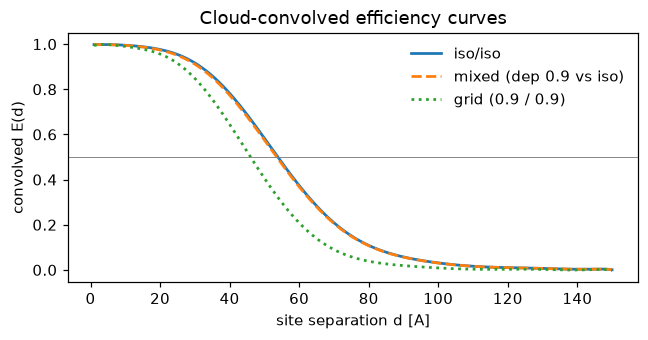

In [4]:
xs = np.arange(1, 151, dtype=float)
fig, ax = plt.subplots(figsize=(6, 3.2), dpi=110)

for label, table, ls in [('iso/iso', table_iso, '-'),
                         ('mixed (dep 0.9 vs iso)', table_mixed, '--'),
                         ('grid (0.9 / 0.9)', table_grid, ':')]:
    idx = bff.nps_orientation_row_index(1.0, 0.0, 1.0, 0.0) if len(table) == 625 \
        else (bff.nps_single_orientation_row_index(1.0, 0.0) if len(table) == 25 else 0)
    ax.plot(xs, np.polyval(table[idx][::-1], xs), ls, label=label, lw=1.8)

ax.axhline(0.5, color='grey', lw=0.6)
ax.set_xlabel('site separation d [A]')
ax.set_ylabel('convolved E(d)')
ax.set_title('Cloud-convolved efficiency curves')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3 · The cloud position prior

`nps_cloud_log_prior` is the weighted Gaussian-KDE log density of the
cloud; `nps_cloud_bandwidth` is Scott's rule on the same cloud. Together
they are the smooth replacement for Fast-NPS's hard box membership. The
prior is built from the *site* cloud (the AV in protein coordinates —
here the acceptor's, centred at x = 45 A):


bandwidth h = 2.44 A, weighted mean = [45.   0.   0.1]


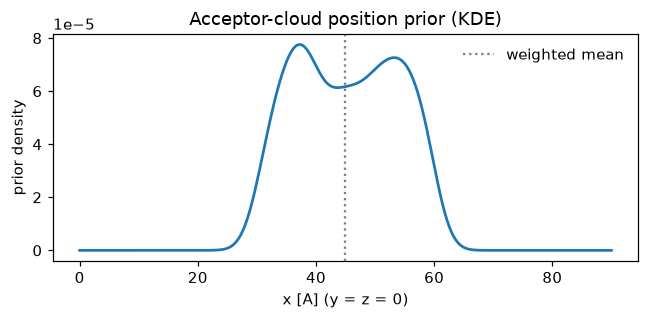

In [5]:
h = bff.nps_cloud_bandwidth(cloud_a)
mean = bff.points_weighted_mean(cloud_a)
print(f'bandwidth h = {h:.2f} A, weighted mean = {np.round(mean, 1)}')

grid = np.linspace(0, 90, 240)
lp = np.array([bff.nps_cloud_log_prior(cloud_a, x, 0.0, 0.0) for x in grid])

fig, ax = plt.subplots(figsize=(6, 3.0), dpi=110)
ax.plot(grid, np.exp(lp), lw=1.8)
ax.axvline(mean[0], color='grey', ls=':', label='weighted mean')
ax.set_xlabel('x [A] (y = z = 0)')
ax.set_ylabel('prior density')
ax.set_title('Acceptor-cloud position prior (KDE)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Sampling a label site under the prior

`nps_cloud_prior_score` is $-\lambda \log p_{\rm cloud}$ for one position, with the
Phase-1 conventions (`+inf` for an unscorable position). A seeded Metropolis walk on it
pulls an outside start into the cloud:

In [6]:
rng = np.random.default_rng(1)
x = np.array([60.0, 20.0, -15.0])
s = bff.nps_cloud_prior_score(cloud_a, *x, 1.0)
for _ in range(20000):
    y = x + rng.normal(0.0, 2.0, 3)
    t = bff.nps_cloud_prior_score(cloud_a, *y, 1.0)
    if t <= s or rng.random() < math.exp(-(t - s) / 0.5):
        x, s = y, t

dist_to_mean = np.linalg.norm(x - np.asarray(mean))
print(f'start (60, 20, -15)  ->  final {np.round(x, 1)}')
print(f'distance to cloud mean: {dist_to_mean:.2f} A  ({dist_to_mean / h:.1f} bandwidths)')

start (60, 20, -15)  ->  final [37.9 -2.1 -3.9]
distance to cloud mean: 8.35 A  (3.4 bandwidths)


## 4 · Seeding and evaluating network configs from clouds

`nps_config_from_cloud` seeds a Fast-NPS configuration row from the
cloud's weighted mean (angles isotropic). Config rows stay the `[x, y,
z, m, phi]` layout the evaluator consumes.

In [7]:
row_d = bff.nps_config_from_cloud(cloud_d)
row_a = bff.nps_config_from_cloud(cloud_a)
config = [row_d, row_a]
print('donor row   :', np.round(row_d, 2))
print('acceptor row:', np.round(row_a, 2))

dyes = []
for _ in range(2):
    dye = bff.NPSNetworkDye()
    dye.dep, dye.iso, dye.dist_conv = 0.0, True, False  # r_avg=0: depolarized, angle-free
    dyes.append(dye)
print('direct E at the seeded positions:',
      bff.nps_network_fret_efficiency(config, dyes, 0, 1, r_iso6))

donor row   : [-0.11 -0.06  0.08  0.    0.  ]
acceptor row: [4.496e+01 3.000e-02 8.000e-02 0.000e+00 0.000e+00]
direct E at the seeded positions: 0.7676375469175264


## 5 · The objective node and the sampler

`NPSNetworkObjective` is a GraphNode whose input ports $x_0..x_{3n-1}$
carry one scalar per dye coordinate. Linked to `MCMCSampler`'s parameter
ports, a Markov step never leaves C++. The node publishes either $-\log L$
or $\chi^2$ on its `"chi2"` port.

In [8]:
# one FRET measurement between the two dyes
meas = bff.NPSMeasurement()
meas.dye1, meas.dye2 = 0, 1
meas.fret_active = True
meas.e_avg, meas.e_err = 0.6, 0.05
meas.r_iso6 = r_iso6

node = bff.NPSNetworkObjective(dyes, [meas], 2)
ports = []
for i in range(6):
    p = bff.GraphPort([0.0])
    ports.append(p)
    link = bff.GraphPort([0.0])
    link.set_link(p)
    node.add_input_port('x%d' % i, link)
node.add_output_port('chi2', bff.GraphPort([0.0]))
node.set_output_is_log_likelihood(True)

# E = 0.6 with kappa^2 = 2/3: (r/R0)^6 = (1-E)/E = 2/3, so the
# likelihood constrains r ~ R0 (2/3)^(1/6) = 51.4 A
r_opt = R0 * (2.0 / 3.0) ** (1.0 / 6.0)
print(f'E = 0.6 at R0 = {R0} A  ->  optimal separation {r_opt:.1f} A')

E = 0.6 at R0 = 55.0 A  ->  optimal separation 51.4 A


chain rows: (6400, 6) | acceptance: 0.72


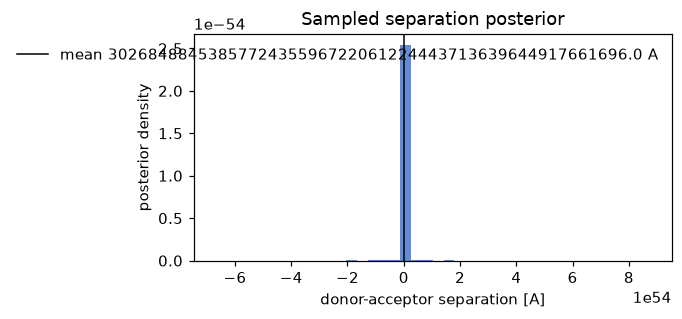

In [9]:
sampler = bff.MCMCSampler('stretch', 11)
sampler.set_parameter_ports(ports)
sampler.set_objective(node, 'chi2')
sampler.set_output_is_log_likelihood(True)

rng = np.random.default_rng(4)
start = [[float(v) for v in rng.normal(0.0, 0.5, 6)] for _ in range(16)]
for row in start:
    row[3] += r_opt
sampler.set_walker_start(start)
sampler.run(400)

chain = np.asarray(sampler.get_chain())
print('chain rows:', chain.shape, '| acceptance: %.2f' % sampler.get_acceptance_rate())

sep = chain[:, 3] - chain[:, 0]
fig, ax = plt.subplots(figsize=(6, 3.0), dpi=110)
ax.hist(sep, bins=40, density=True, color='#4878cf', alpha=0.85)
ax.axvline(sep.mean(), color='k', lw=1, label='mean %.1f A' % sep.mean())
ax.set_xlabel('donor-acceptor separation [A]')
ax.set_ylabel('posterior density')
ax.set_title('Sampled separation posterior')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The absolute positions are flat directions (the likelihood is
translation-invariant) — the diagnostics report that honestly:

In [10]:
ce = bff.nps_cross_entropy(sampler.get_chi2(), sampler.get_lnprior())
mcse = bff.nps_mean_mcse([list(map(float, r)) for r in
                          np.asarray(sampler.get_chain_of_walker(0))])
print(f'cross-entropy of the chain: {ce:.3f}')
print('per-coordinate MCSE:', np.round(mcse, 3))
print('  (separation coordinate, x3:', '%.3g' % mcse[3],
      '- identifiable; absolute positions are flat, MCSE large)')

# chi-square consistency: min chi2 over the chain vs the data's dof (1 here)
chi2 = np.asarray(sampler.get_chi2())
print('min chi2 over the chain: %.3f  (dof = 1)' % chi2.min())

cross-entropy of the chain: -67.799
per-coordinate MCSE: [2.63677593e+53 4.24552845e+53 4.65488038e+53 4.21011689e+53
 7.40648263e+53 3.78682641e+53]
  (separation coordinate, x3: 4.21e+53 - identifiable; absolute positions are flat, MCSE large)
min chi2 over the chain: -139.846  (dof = 1)


## 6 · Tables feeding the evaluator end to end

The generated table plugs straight into the convolved branch: the
measurement carries `eff_conv_coeff`, the dyes flag `dist_conv`, and the
evaluator picks row 0 (iso/iso) at the config's site separation.


In [11]:
meas_grid = bff.NPSMeasurement()
meas_grid.dye1, meas_grid.dye2 = 0, 1
meas_grid.fret_active = True
meas_grid.e_avg, meas_grid.e_err = 0.55, 0.05
meas_grid.r_iso6 = r_iso6
meas_grid.set_eff_conv_coeff(table_iso)   # iso/iso: row 0 is used

dyes_conv = []
for _ in range(2):
    dye = bff.NPSNetworkDye()
    dye.dep, dye.iso, dye.dist_conv = 1.0, True, True  # distance-convolved
    dyes_conv.append(dye)

site_sep = np.linalg.norm(np.asarray(row_a[:3]) - np.asarray(row_d[:3]))
e_conv = bff.nps_network_fret_efficiency(config, dyes_conv, 0, 1, r_iso6,
                                         table_iso)
print(f'site separation: {site_sep:.1f} A')
print('convolved E (cloud table):', round(e_conv, 4))

logl = bff.nps_network_log_likelihood(config, dyes_conv, [meas_grid])
print('network log L           :', round(logl, 4))


site separation: 45.1 A
convolved E (cloud table): 0.6868
network log L           : -1.6658


## References

- Muschielok A, Michaelis J. *Application of the Nano-Positioning System
  to the determination of a molecular mechanism by fluorescence
  spectroscopy*, ChemPhysChem 2017, doi:10.1016/j.cpc.2017.05.027
- Scott DW. *Multivariate Density Estimation*, Wiley 1992,
  doi:10.1111/j.2517-6161.1992.tb01796.x
- Vehtari A, Gelman A, Simpson D, Carpenter B, Bürkner P-C. *Rank-normalized
  split R-hat and ESS*, Bayesian Analysis 2021, doi:10.1214/20-BA1221